In [82]:
import fuzzywuzzy
import pandas as pd
import numpy as np
import seaborn as sns
from fuzzywuzzy import process, fuzz

In [40]:
# E1: exploring missing values, using Building_Permit.py to create csv and then importing it

building_permit_df = pd.read_csv("../data/Building_Permits.csv")
print(building_permit_df.head(5))

missing_value_count = building_permit_df.isnull().sum()
print(missing_value_count[0:10])

/tmp/ipykernel_20720/1874666916.py:3: DtypeWarning: Columns (0: Voluntary Soft-Story Retrofit, 1: TIDF Compliance) have mixed types. Specify dtype option on import or set low_memory=False.
  building_permit_df = pd.read_csv("../data/Building_Permits.csv")


  Permit Number  Permit Type            Permit Type Definition  \
0  201505065519            4                      sign - erect   
1  201604195146            4                      sign - erect   
2  201605278609            3  additions alterations or repairs   
3  201611072166            8            otc alterations permit   
4  201611283529            6                       demolitions   

  Permit Creation Date Block  Lot  Street Number Street Number Suffix  \
0           05/06/2015  0326  023            140                  NaN   
1           04/19/2016  0306  007            440                  NaN   
2           05/27/2016  0595  203           1647                  NaN   
3           11/07/2016  0156  011           1230                  NaN   
4           11/28/2016  0342  001            950                  NaN   

  Street Name Street Suffix  ...  Existing Construction Type  \
0       Ellis            St  ...                         3.0   
1       Geary            St  ...    

In [41]:
total_cells = np.prod(building_permit_df.shape)
total_missing = missing_value_count.sum()

missing_percentage = (total_missing/total_cells) * 100

print(f"Missing percentage: {missing_percentage.round(2)}")

top_missing_count = 2
print(f"Top {top_missing_count} columns with most missing are: ")
top_missing = missing_value_count.sort_values(ascending=False)
print(top_missing.head(top_missing_count))

Missing percentage: 26.26
Top 2 columns with most missing are: 
TIDF Compliance                  198898
Voluntary Soft-Story Retrofit    198865
dtype: int64


In [42]:
# E2: Hospital Record cleaning

hospital_record = pd.read_csv("../data/hospital data analysis.csv")
print(hospital_record.head(5))

missing_drop = hospital_record.dropna()
missing_drop_axis = hospital_record.dropna(axis=1)

print("Missing dropna shape : ", missing_drop.shape)
print("Missing axis shape: ", missing_drop_axis.shape)

   Patient_ID  Age  Gender      Condition                 Procedure   Cost  \
0           1   45  Female  Heart Disease               Angioplasty  15000   
1           2   60    Male       Diabetes           Insulin Therapy   2000   
2           3   32  Female  Fractured Arm          X-Ray and Splint    500   
3           4   75    Male         Stroke    CT Scan and Medication  10000   
4           5   50  Female         Cancer  Surgery and Chemotherapy  25000   

   Length_of_Stay Readmission    Outcome  Satisfaction  
0               5          No  Recovered             4  
1               3         Yes     Stable             3  
2               1          No  Recovered             5  
3               7         Yes     Stable             2  
4              10          No  Recovered             4  
Missing dropna shape :  (984, 10)
Missing axis shape:  (984, 10)


In [43]:
# E3: using dubia housing data to fill missing

housing_df = pd.read_csv("../data/rentals.csv")
print(housing_df.head(5))

bfill_housing = housing_df.bfill()
fillna_housing = housing_df.fillna(0)

print("Bfill housing : ", fillna_housing)
print("Bfill axis : ", fillna_housing)

        id date_listed      community           zone       lat       lon  \
0  R000001  2024-12-20    Town Square         Nshama  25.02906  55.25610   
1  R000002  2021-07-06      Expo City    Dubai South  24.96152  55.15759   
2  R000003  2023-05-10  Palm Jumeirah  Palm Jumeirah  25.10836  55.13304   
3  R000004  2021-12-30          Deira          Deira  25.28720  55.30205   
4  R000005  2023-12-08      The Views     The Greens  25.08438  55.18399   

  property_category property_type  bedrooms  area_sqft  ...  parking_spaces  \
0         apartment           1BR         1        748  ...               1   
1         apartment           1BR         1       1011  ...               2   
2         apartment           1BR         1        825  ...               2   
3         apartment           1BR         1        755  ...               1   
4         apartment           1BR         1        746  ...               1   

         metro_station metro_line  metro_distance_min  to_burj_khali

In [62]:
# E4: parsing dates in crime dataset

crime_df = pd.read_csv("../data/Crime_Data_from_2020_to_Present.csv")
print(crime_df.columns.tolist())
print(crime_df.head(3))

print(crime_df['DATE OCC'].head())
print(crime_df['DATE OCC'].dtype)

crime_df['date_parsed'] = pd.to_datetime(crime_df['DATE OCC'], format='%m/%d/%Y %I:%M:%S %p')
print(crime_df['date_parsed'].head(3))

crime_df['day'] = crime_df['date_parsed'].dt.day
crime_df['month'] = crime_df['date_parsed'].dt.month

print(crime_df['day'].head(3))
print(crime_df['month'].head(3))


['DR_NO', 'Date Rptd', 'DATE OCC', 'TIME OCC', 'AREA', 'AREA NAME', 'Rpt Dist No', 'Part 1-2', 'Crm Cd', 'Crm Cd Desc', 'Mocodes', 'Vict Age', 'Vict Sex', 'Vict Descent', 'Premis Cd', 'Premis Desc', 'Weapon Used Cd', 'Weapon Desc', 'Status', 'Status Desc', 'Crm Cd 1', 'Crm Cd 2', 'Crm Cd 3', 'Crm Cd 4', 'LOCATION', 'Cross Street', 'LAT', 'LON']
       DR_NO               Date Rptd                DATE OCC  TIME OCC  AREA  \
0  190326475  03/01/2020 12:00:00 AM  03/01/2020 12:00:00 AM      2130     7   
1  200106753  02/09/2020 12:00:00 AM  02/08/2020 12:00:00 AM      1800     1   
2  200320258  11/11/2020 12:00:00 AM  11/04/2020 12:00:00 AM      1700     3   

   AREA NAME  Rpt Dist No  Part 1-2  Crm Cd            Crm Cd Desc  ...  \
0   Wilshire          784         1     510       VEHICLE - STOLEN  ...   
1    Central          182         1     330  BURGLARY FROM VEHICLE  ...   
2  Southwest          356         1     480          BIKE - STOLEN  ...   

  Status   Status Desc Crm Cd 1

<Axes: xlabel='day', ylabel='Count'>

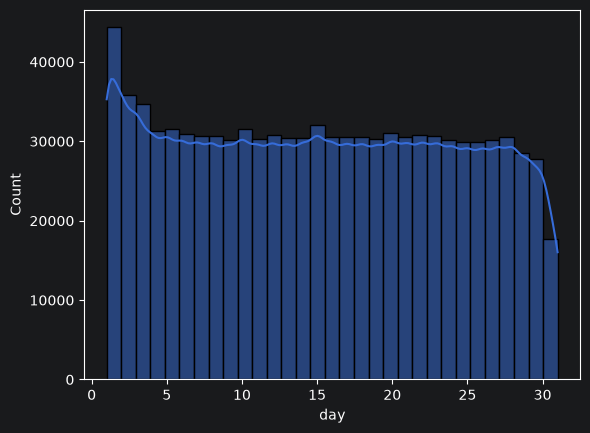

In [72]:
# E5: creating visual of parsed date

month_to_plot = crime_df['day'].dropna()
sns.histplot(month_to_plot, kde=True, bins=31)

In [78]:
# E6: Restaurants review analysis

restaurants_df = pd.read_csv("../data/North America Restaurants.csv")
print(restaurants_df.head(3))

rest_cities = sorted(restaurants_df.city.unique())
print(rest_cities)

rest_cities = restaurants_df.city.str.lower().str.strip()
print(rest_cities)


           name         city state zipcode country  \
0   Burger King    Manitowoc    WI   54220      US   
1  Petro-Canada      Airdrie    AB     T4A      CA   
2      Boba Bae  Ashwaubenon    WI   54304      US   

                                            cuisines  pickup_enabled  \
0  American, Burger, Burgers, Family Meals, Fast ...            True   
1  Ben & Jerry's, Café/Thé, Coffee/Tea, Convenien...            True   
2  American, Asian Food, Bubble Tea, Coffee & Tea...            True   

   delivery_enabled  weighted_rating_value  aggregated_rating_count  
0              True                    2.4                       42  
1              True                    4.1                        1  
2              True                    4.0                       88  
['Abilene', 'Acworth', 'Airdrie', 'Akron', 'Albuquerque', 'Alexandria', 'Alhambra', 'Allentown', 'Altamonte Springs', 'American Fork', 'Americus', 'Ames', 'Amherst', 'Anchorage', 'Angleton', 'Antioch', 'Appleton', 

In [85]:
# E7: Fuzzy matching

target_city = "Melbourne"
matches = process.extract(target_city, rest_cities, scorer=fuzz.ratio, limit=10)
print(matches)
print()

def replace_matches_in_column(df, column, string_to_match, min_ratio=90):
    for value in df[column].unique():
        ratio = fuzz.ratio(string_to_match, value)

        if ratio >= min_ratio:
            df[column] = df[column].replace(value, string_to_match)

    return df

restaurants_df = replace_matches_in_column(
    restaurants_df,
    "city",
    target_city,
    min_ratio=90
)

rest_cities = sorted(restaurants_df.city.unique())
print(rest_cities)

[('Melbourne', 100), ('West Melbourne', 78), ('Lilburn', 62), ('Dearborn', 59), ('Boone', 57), ('Auburn', 53), ('Terrebonne', 53), ('Albuquerque', 50), ('Boulder', 50), ('Burnaby', 50)]

['Abilene', 'Acworth', 'Airdrie', 'Akron', 'Albuquerque', 'Alexandria', 'Alhambra', 'Allentown', 'Altamonte Springs', 'American Fork', 'Americus', 'Ames', 'Amherst', 'Anchorage', 'Angleton', 'Antioch', 'Appleton', 'Arden Hills', 'Arlington', 'Ashwaubenon', 'Atlanta', 'Atlantic City', 'Attleboro', 'Auburn', 'Aurora', 'Austin', 'Aventura', 'Avondale', 'Bakersfield', 'Baltimore', 'Bangor', 'Barrie', 'Bella Vista', 'Bellevue', 'Bensenville', 'Bentonville', 'Berkeley', 'Bessemer', 'Bethesda', 'Beverly Hills', 'Biloxi', 'Binghamton', 'Bismarck', 'Blaine', 'Blainville', 'Bloomington', 'Boone', 'Boston', 'Boulder', 'Bowmanville', 'Boynton Beach', 'Bradenton', 'Bradford', 'Brampton', 'Brandenton', 'Brandon', 'Bridgeville', 'Bronx', 'Brookfield', 'Brooklyn', 'Broomfield', 'Brossard', 'Buffalo', 'Burlington', 'Bu